In [36]:
import warnings
warnings.filterwarnings("ignore")

import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [37]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [38]:
PROJECT_DIR = "/content/drive/MyDrive/Ghana_Dropout_Project"

RESULT_DIR = f"{PROJECT_DIR}/results"

FIGURE_DIR = f"{PROJECT_DIR}/figures"

os.makedirs(FIGURE_DIR, exist_ok=True)

In [39]:
baseline = pd.read_csv(
    f"{RESULT_DIR}/baseline_cv_results.csv"
)

augmentation = pd.read_csv(
    f"{RESULT_DIR}/augmentation_results.csv"
)

engineered = pd.read_csv(
    f"{RESULT_DIR}/engineered_lightgbm_results.csv"
)

In [40]:
baseline = baseline.rename(columns={
    "F1":"F1 Score",
    "ROC_AUC":"ROC-AUC",
    "PR_AUC":"PR-AUC"
})

augmentation = augmentation.rename(columns={
    "F1":"F1 Score",
    "ROC_AUC":"ROC-AUC",
    "PR_AUC":"PR-AUC"
})

augmentation["Model"] = augmentation["Experiment"]

engineered = engineered.rename(columns={
    "F1":"F1 Score",
    "ROC_AUC":"ROC-AUC",
    "PR_AUC":"PR-AUC"
})

if "Model" not in engineered.columns:
    engineered.insert(
        0,
        "Model",
        "Engineered LightGBM"
    )

comparison = pd.concat(
    [
        baseline,
        augmentation,
        engineered
    ],
    ignore_index=True,
    sort=False
)

comparison = comparison[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "PR-AUC"
    ]
]

comparison["Category"] = "Baseline"

comparison.loc[
    comparison["Model"].isin(
        ["Original","SMOTE","CTGAN"]
    ),
    "Category"
] = "Augmentation"

comparison.loc[
    comparison["Model"]=="Engineered LightGBM",
    "Category"
] = "Proposed"

In [41]:
baseline_results = comparison[
    comparison["Category"]=="Baseline"
].copy()

baseline_results = baseline_results.drop(
    columns=["PR-AUC"],
    errors="ignore"
)

baseline_results = baseline_results.sort_values(
    by=["F1 Score","ROC-AUC"],
    ascending=False
).reset_index(drop=True)

baseline_results.insert(
    0,
    "Rank",
    range(1,len(baseline_results)+1)
)

baseline_results

,Rank,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Category
0,1,CatBoost,0.992,0.977709,0.935088,0.955505,0.990971,Baseline
1,2,LightGBM,0.991,0.969474,0.935088,0.950620,0.980500,Baseline
2,3,XGBoost,0.989,0.968235,0.913450,0.938901,0.984278,Baseline
3,4,Random Forest,0.989,1.000000,0.880702,0.936085,0.996908,Baseline
4,5,Logistic Regression,0.987,0.916257,0.946199,0.930299,0.975017,Baseline
5,6,Decision Tree,0.985,0.922222,0.924561,0.920391,0.957876,Baseline


In [42]:
baseline_results.to_csv(
    f"{RESULT_DIR}/baseline_ranking.csv",
    index=False
)

In [43]:
def plot_metric(df,
                metric,
                title,
                xmin=None):

    data = df.sort_values(metric)

    plt.figure(figsize=(9,5))

    bars = plt.barh(
        data["Model"],
        data[metric],
        edgecolor="black"
    )

    if xmin is not None:
        plt.xlim(xmin,1)

    plt.title(title,
              fontsize=14,
              fontweight="bold")

    plt.xlabel(metric)

    plt.grid(axis="x",alpha=.3)

    for bar in bars:

        value = bar.get_width()

        plt.text(
            value+0.001,
            bar.get_y()+bar.get_height()/2,
            f"{value:.4f}",
            va="center"
        )

    plt.tight_layout()

    filename = (
        title.lower()
        .replace(" ", "_")
        .replace("-", "_")
    )

    plt.savefig(
        f"{FIGURE_DIR}/{filename}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

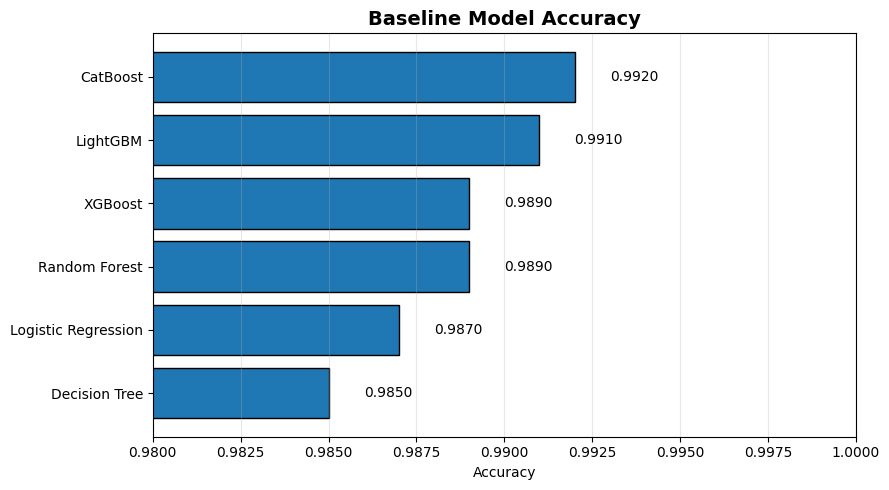

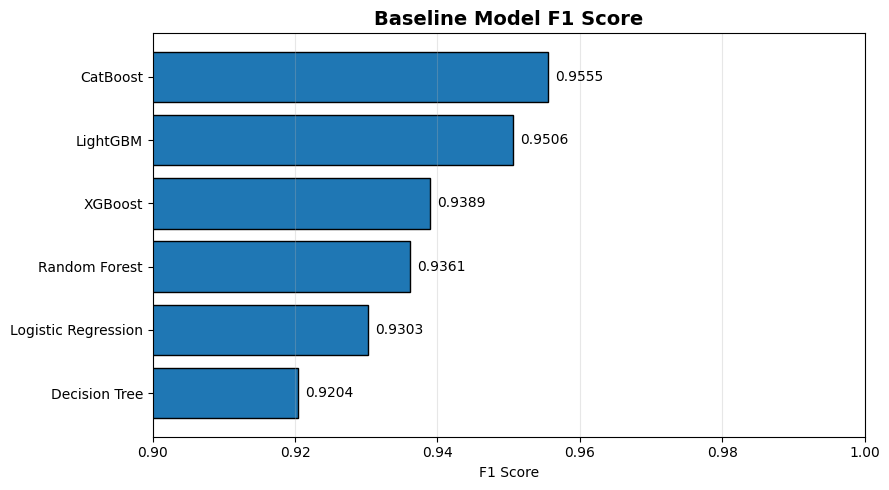

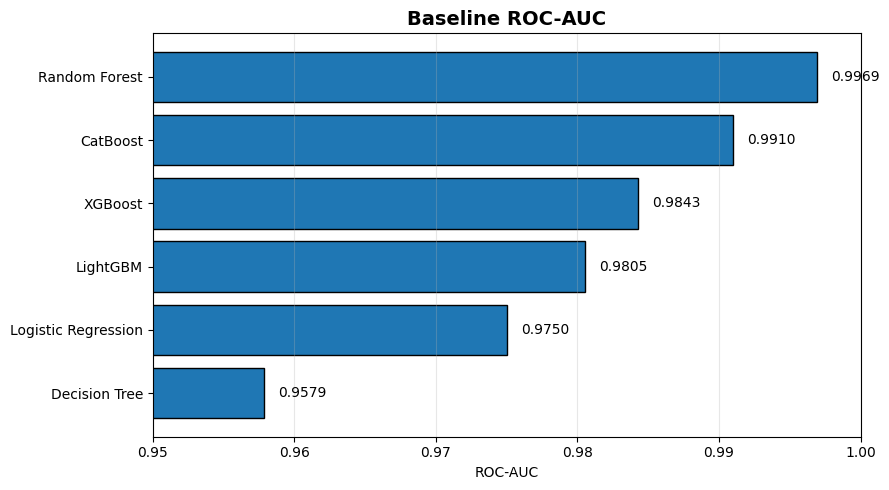

In [44]:
plot_metric(
    baseline_results,
    "Accuracy",
    "Baseline Model Accuracy",
    0.98
)

plot_metric(
    baseline_results,
    "F1 Score",
    "Baseline Model F1 Score",
    0.90
)

plot_metric(
    baseline_results,
    "ROC-AUC",
    "Baseline ROC-AUC",
    0.95
)

In [45]:
augmentation_results = comparison[
    comparison["Category"]=="Augmentation"
].copy()

augmentation_results = augmentation_results.sort_values(
    by=["PR-AUC","ROC-AUC"],
    ascending=False
).reset_index(drop=True)

augmentation_results.insert(
    0,
    "Rank",
    range(1,len(augmentation_results)+1)
)

augmentation_results

,Rank,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC,Category
0,1,SMOTE,0.995,1.0,0.944444,0.971429,0.998474,0.987923,Augmentation
1,2,Original,0.995,1.0,0.944444,0.971429,0.997863,0.984444,Augmentation
2,3,CTGAN,0.995,1.0,0.944444,0.971429,0.995421,0.974747,Augmentation


In [46]:
augmentation_results.to_csv(
    f"{RESULT_DIR}/augmentation_ranking.csv",
    index=False
)

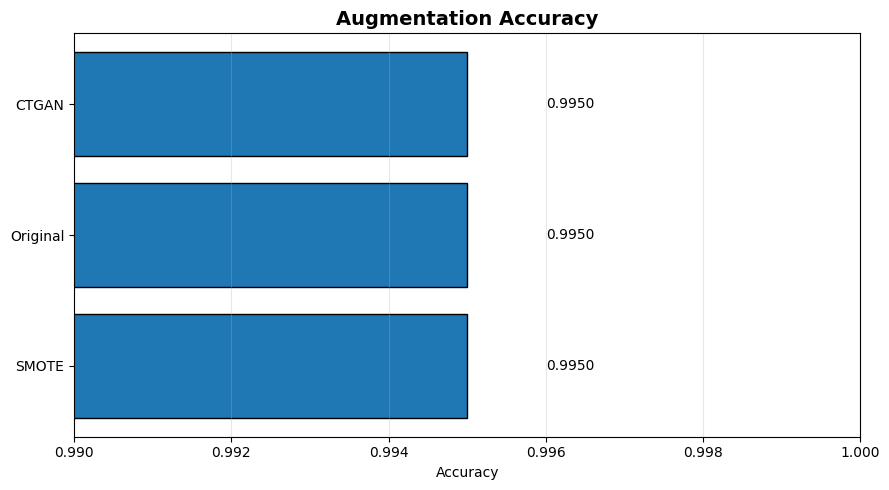

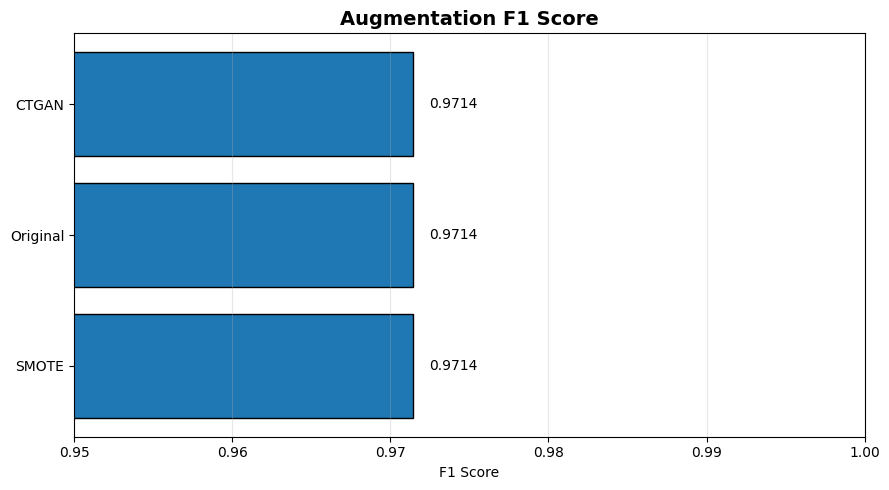

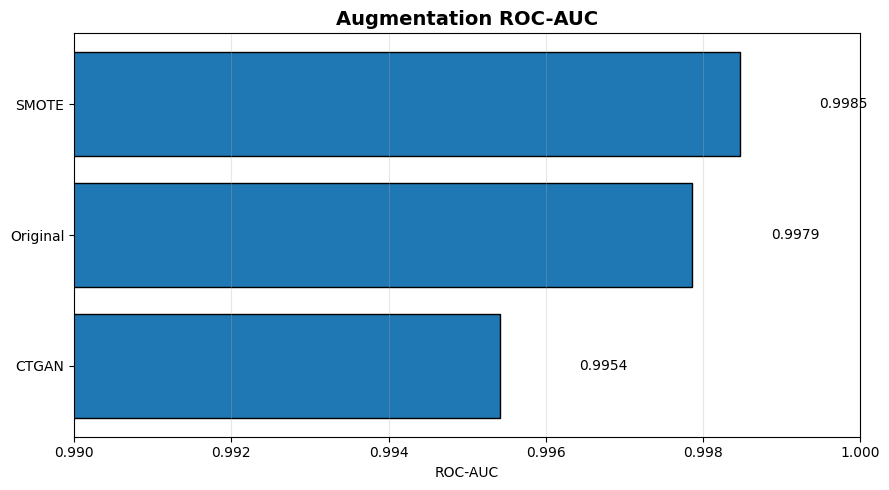

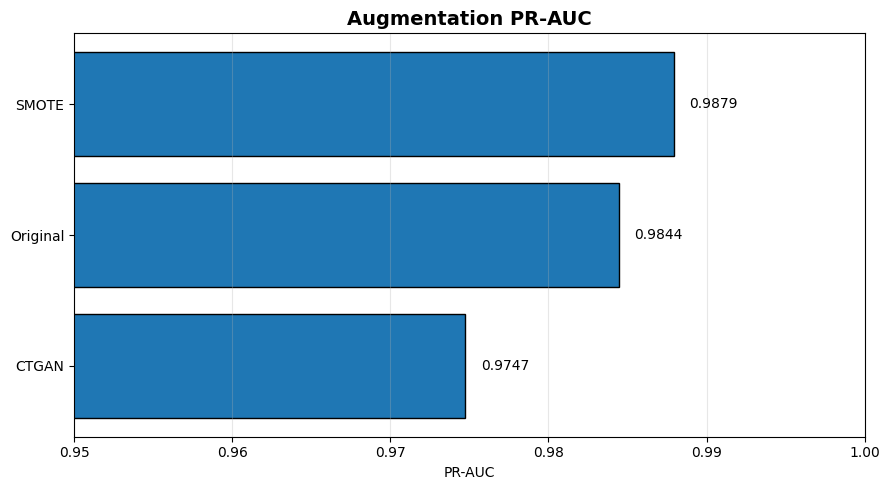

In [47]:
plot_metric(
    augmentation_results,
    "Accuracy",
    "Augmentation Accuracy",
    0.99
)

plot_metric(
    augmentation_results,
    "F1 Score",
    "Augmentation F1 Score",
    0.95
)

plot_metric(
    augmentation_results,
    "ROC-AUC",
    "Augmentation ROC-AUC",
    0.99
)

plot_metric(
    augmentation_results,
    "PR-AUC",
    "Augmentation PR-AUC",
    0.95
)

In [48]:
proposed = comparison[
    comparison["Category"]=="Proposed"
].copy()

proposed

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC,Category
9,Engineered LightGBM,0.995,1.0,0.944444,0.971429,0.996337,0.977778,Proposed


In [49]:
proposed.to_csv(
    f"{RESULT_DIR}/proposed_model_results.csv",
    index=False
)

In [50]:
shap = pd.read_csv(
    f"{RESULT_DIR}/shap_feature_importance.csv"
)

shap.head(20)

,Feature,Mean |SHAP|
0,term_2_attendance,0.826233
1,average_exam_score,0.826203
2,family_income_level,0.551774
3,term_1_attendance,0.411226
4,term_3_attendance,0.356725
5,science_exam_score,0.281637
6,school_type,0.226950
7,school_code,0.144419
8,social_studies_exam_score,0.111440
9,class_participation,0.099459


In [51]:
summary = pd.DataFrame({

    "Category":[
        "Baseline",
        "Data Augmentation",
        "Proposed Model"
    ],

    "Best Method":[
        baseline_results.iloc[0]["Model"],
        augmentation_results.iloc[0]["Model"],
        proposed.iloc[0]["Model"]
    ],

    "Accuracy":[
        baseline_results.iloc[0]["Accuracy"],
        augmentation_results.iloc[0]["Accuracy"],
        proposed.iloc[0]["Accuracy"]
    ],

    "Precision":[
        baseline_results.iloc[0]["Precision"],
        augmentation_results.iloc[0]["Precision"],
        proposed.iloc[0]["Precision"]
    ],

    "Recall":[
        baseline_results.iloc[0]["Recall"],
        augmentation_results.iloc[0]["Recall"],
        proposed.iloc[0]["Recall"]
    ],

    "F1 Score":[
        baseline_results.iloc[0]["F1 Score"],
        augmentation_results.iloc[0]["F1 Score"],
        proposed.iloc[0]["F1 Score"]
    ],

    "ROC-AUC":[
        baseline_results.iloc[0]["ROC-AUC"],
        augmentation_results.iloc[0]["ROC-AUC"],
        proposed.iloc[0]["ROC-AUC"]
    ],

    "PR-AUC":[
        "—",
        augmentation_results.iloc[0]["PR-AUC"],
        proposed.iloc[0]["PR-AUC"]
    ]

})

summary

,Category,Best Method,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Baseline,CatBoost,0.992,0.977709,0.935088,0.955505,0.990971,—
1,Data Augmentation,SMOTE,0.995,1.000000,0.944444,0.971429,0.998474,0.987923
2,Proposed Model,Engineered LightGBM,0.995,1.000000,0.944444,0.971429,0.996337,0.977778


In [52]:
summary.to_csv(
    f"{RESULT_DIR}/chapter4_summary.csv",
    index=False
)

In [53]:
print("=" * 70)
print("FINAL RESULTS SUMMARY")
print("=" * 70)

display(summary)

print("\nBest Baseline Model:")
print(f"  {baseline_results.iloc[0]['Model']}")

print("\nBest Data Augmentation Method:")
print(f"  {augmentation_results.iloc[0]['Model']}")

print("\nProposed Model:")
print(f"  {proposed.iloc[0]['Model']}")

print("=" * 70)

FINAL RESULTS SUMMARY


,Category,Best Method,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Baseline,CatBoost,0.992,0.977709,0.935088,0.955505,0.990971,—
1,Data Augmentation,SMOTE,0.995,1.000000,0.944444,0.971429,0.998474,0.987923
2,Proposed Model,Engineered LightGBM,0.995,1.000000,0.944444,0.971429,0.996337,0.977778



Best Baseline Model:
  CatBoost

Best Data Augmentation Method:
  SMOTE

Proposed Model:
  Engineered LightGBM


In [54]:
print("=" * 70)
print("FINAL RESULTS SUMMARY")
print("=" * 70)

display(summary)

print("\nBest Baseline Model:")
print(f"  {baseline_results.iloc[0]['Model']}")

print("\nBest Data Augmentation Method:")
print(f"  {augmentation_results.iloc[0]['Model']}")

print("\nProposed Model:")
print(f"  {proposed.iloc[0]['Model']}")

print("=" * 70)

FINAL RESULTS SUMMARY


,Category,Best Method,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Baseline,CatBoost,0.992,0.977709,0.935088,0.955505,0.990971,—
1,Data Augmentation,SMOTE,0.995,1.000000,0.944444,0.971429,0.998474,0.987923
2,Proposed Model,Engineered LightGBM,0.995,1.000000,0.944444,0.971429,0.996337,0.977778



Best Baseline Model:
  CatBoost

Best Data Augmentation Method:
  SMOTE

Proposed Model:
  Engineered LightGBM


In [55]:
# =====================================================
# SHAP Feature Importance
# =====================================================

shap_results = pd.read_csv(
    f"{RESULT_DIR}/shap_feature_importance.csv"
)

display(shap_results.head(20))

,Feature,Mean |SHAP|
0,term_2_attendance,0.826233
1,average_exam_score,0.826203
2,family_income_level,0.551774
3,term_1_attendance,0.411226
4,term_3_attendance,0.356725
5,science_exam_score,0.281637
6,school_type,0.226950
7,school_code,0.144419
8,social_studies_exam_score,0.111440
9,class_participation,0.099459


In [56]:
# =====================================================
# Overall Best Models
# =====================================================

summary = pd.DataFrame({

    "Category":[
        "Baseline",
        "Data Augmentation",
        "Proposed"
    ],

    "Best Model":[
        baseline_results.iloc[0]["Model"],
        augmentation_results.iloc[0]["Model"],
        proposed.iloc[0]["Model"]
    ],

    "Accuracy":[
        baseline_results.iloc[0]["Accuracy"],
        augmentation_results.iloc[0]["Accuracy"],
        proposed.iloc[0]["Accuracy"]
    ],

    "Precision":[
        baseline_results.iloc[0]["Precision"],
        augmentation_results.iloc[0]["Precision"],
        proposed.iloc[0]["Precision"]
    ],

    "Recall":[
        baseline_results.iloc[0]["Recall"],
        augmentation_results.iloc[0]["Recall"],
        proposed.iloc[0]["Recall"]
    ],

    "F1 Score":[
        baseline_results.iloc[0]["F1 Score"],
        augmentation_results.iloc[0]["F1 Score"],
        proposed.iloc[0]["F1 Score"]
    ],

    "ROC-AUC":[
        baseline_results.iloc[0]["ROC-AUC"],
        augmentation_results.iloc[0]["ROC-AUC"],
        proposed.iloc[0]["ROC-AUC"]
    ],

    "PR-AUC":[
        np.nan,
        augmentation_results.iloc[0]["PR-AUC"],
        proposed.iloc[0]["PR-AUC"]
    ]

})

summary

,Category,Best Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Baseline,CatBoost,0.992,0.977709,0.935088,0.955505,0.990971,NaN
1,Data Augmentation,SMOTE,0.995,1.000000,0.944444,0.971429,0.998474,0.987923
2,Proposed,Engineered LightGBM,0.995,1.000000,0.944444,0.971429,0.996337,0.977778


In [57]:
summary.to_csv(
    f"{RESULT_DIR}/Table_4_4_Final_Comparison.csv",
    index=False
)

In [58]:
# =====================================================
# Final Excel Workbook
# =====================================================

with pd.ExcelWriter(
    f"{RESULT_DIR}/final_results.xlsx",
    engine="openpyxl"
) as writer:

    baseline_results.to_excel(
        writer,
        sheet_name="Baseline Ranking",
        index=False
    )

    augmentation_results.to_excel(
        writer,
        sheet_name="Augmentation Ranking",
        index=False
    )

    proposed.to_excel(
        writer,
        sheet_name="Proposed Model",
        index=False
    )

    summary.to_excel(
        writer,
        sheet_name="Final Comparison",
        index=False
    )

    shap_results.to_excel(
        writer,
        sheet_name="SHAP Importance",
        index=False
    )

print("Excel workbook saved.")

Excel workbook saved.


In [59]:
print("="*70)
print("FINAL RESULTS")
print("="*70)

print("\nBEST BASELINE MODEL")
print("-------------------------")
print(baseline_results.iloc[0])

print("\nBEST AUGMENTATION METHOD")
print("-------------------------")
print(augmentation_results.iloc[0])

print("\nPROPOSED MODEL")
print("-------------------------")
print(proposed.iloc[0])

print("\nFINAL COMPARISON")
print("-------------------------")
display(summary)

FINAL RESULTS

BEST BASELINE MODEL
-------------------------
Rank                1
Model        CatBoost
Accuracy        0.992
Precision    0.977709
Recall       0.935088
F1 Score     0.955505
ROC-AUC      0.990971
Category     Baseline
Name: 0, dtype: object

BEST AUGMENTATION METHOD
-------------------------
Rank                    1
Model               SMOTE
Accuracy            0.995
Precision             1.0
Recall           0.944444
F1 Score         0.971429
ROC-AUC          0.998474
PR-AUC           0.987923
Category     Augmentation
Name: 0, dtype: object

PROPOSED MODEL
-------------------------
Model        Engineered LightGBM
Accuracy                   0.995
Precision                    1.0
Recall                  0.944444
F1 Score                0.971429
ROC-AUC                 0.996337
PR-AUC                  0.977778
Category                Proposed
Name: 9, dtype: object

FINAL COMPARISON
-------------------------


,Category,Best Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Baseline,CatBoost,0.992,0.977709,0.935088,0.955505,0.990971,NaN
1,Data Augmentation,SMOTE,0.995,1.000000,0.944444,0.971429,0.998474,0.987923
2,Proposed,Engineered LightGBM,0.995,1.000000,0.944444,0.971429,0.996337,0.977778


In [60]:
print("=" * 70)
print("KEY FINDINGS")
print("=" * 70)

print(f"• Best baseline model: {baseline_results.iloc[0]['Model']}")
print(f"• Best augmentation method: {augmentation_results.iloc[0]['Model']}")
print(f"• Proposed model: {proposed.iloc[0]['Model']}")

print(f"\nBest baseline F1 Score: {baseline_results.iloc[0]['F1 Score']:.4f}")
print(f"Best augmentation F1 Score: {augmentation_results.iloc[0]['F1 Score']:.4f}")
print(f"Proposed model F1 Score: {proposed.iloc[0]['F1 Score']:.4f}")

print("\nNotebook 8 completed successfully.")

KEY FINDINGS
• Best baseline model: CatBoost
• Best augmentation method: SMOTE
• Proposed model: Engineered LightGBM

Best baseline F1 Score: 0.9555
Best augmentation F1 Score: 0.9714
Proposed model F1 Score: 0.9714

Notebook 8 completed successfully.
